# 07: stats

`fxcarry.stats` describes return series and estimates things from them. Nothing in this module
knows what a currency is, or that any of the numbers behind it ever came from an FX forward.
`Performance` describes one series, or a frame of several. `HAC` is a lag choice packaged as an
object, producing standard errors that stop assuming returns are independent from one period to
the next. `Realized` turns daily observations into a period volatility. `FactorModel` and
`LinearSDF` are the two estimators in the repository that ask whether a set of factors explains a
set of returns: one runs a regression per asset, the other estimates a single stochastic discount
factor across all of them at once. `RollingOLS` and `Shrinkage` are domain-free tools that happen
to get used on FX data here only because that is what the rest of the repository produces.

This notebook rebuilds the same book notebook 06 built: `Carry` scored, `TopBottom(5)` weighted,
no cost model, no overlay. Everything below asks something of that one return series, and section
7 additionally asks something of the daily spot panel underneath it.

In [1]:
import pathlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

# nbconvert runs with this notebook's folder as the working directory, so walk up
# rather than assume how deep the notebook sits.
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "data" / "raw").is_dir())
DATA = ROOT / "data" / "raw"
TAU = 1.0 / 12.0

## Setup: the book from notebook 06, plus the daily panel section 7 needs

This notebook is self-contained, so it rebuilds `curves`, `catalog` and `book` exactly as
notebook 06 did rather than importing anything from it. Section 7 additionally needs the daily
spot panel, since `Realized` estimates volatility from higher-frequency data than the monthly
returns everything else here uses. Loading it now, once, rather than inside section 7 keeps every
cell below free of a data pull it does not itself perform. Unlike notebook 06's vol surface, this
is a plain daily pivot of one field with nothing to filter, so bringing it in early costs nothing
worth timing.

In [2]:
from fxcarry import Book, Carry, Catalog, ParquetSource, SpotForward, TopBottom

catalog = Catalog.default()
source = ParquetSource(DATA / "spot_daily.parquet", DATA / "fwd_points_1m_daily.parquet")
spot = source.quotes(catalog.label_map("spot"), freq="M")
points = source.quotes(catalog.label_map("forward", "1M"), freq="M")
curves = SpotForward.from_quotes(spot, points, catalog, TAU)
book = Book(curves, Carry(), TopBottom(5))
daily = ParquetSource(DATA / "spot_daily.parquet").panel(catalog.label_map("spot"))

r_all = book.returns().dropna()
print(f"{len(curves.currencies)} currencies, {len(curves.spot.index)} months, "
      f"{curves.spot.index[0]:%Y-%m} to {curves.spot.index[-1]:%Y-%m}")
print(f"book returns: {len(r_all)} months, {r_all.index[0]:%Y-%m} to {r_all.index[-1]:%Y-%m}")
print(f"daily spot panel: {daily.shape[0]} rows, {daily.shape[1]} currencies, "
      f"{daily.index.min():%Y-%m-%d} to {daily.index.max():%Y-%m-%d}")

23 currencies, 513 months, 1983-11 to 2026-07
book returns: 511 months, 1984-01 to 2026-07
daily spot panel: 11652 rows, 26 currencies, 1983-11-01 to 2026-07-15


## Performance, property by property

`Performance` wraps one return series and reports what it did. There is no fit step: every
property below is a closed-form statistic read straight off `book.returns()`.

In [3]:
from fxcarry import HAC, Performance

perf = Performance(book.returns())
pd.Series({"mean": perf.mean, "volatility": perf.volatility, "sharpe": perf.sharpe,
           "skew": perf.skew, "excess kurtosis": perf.kurtosis, "win rate": perf.win_rate,
           "worst month": perf.worst, "max drawdown": perf.max_drawdown,
           "5% cvar": perf.cvar(0.05)}).round(4)

mean               0.0606
volatility         0.0665
sharpe             0.9117
skew              -0.3786
excess kurtosis    1.5129
win rate           0.6282
worst month       -0.0787
max drawdown      -0.1952
5% cvar           -0.0425
dtype: float64

Three annualization choices sit inside that table. `mean`, `volatility` and `sharpe` are scaled
by `periods_per_year`, twelve here, so they read as yearly rates. `skew` and `kurtosis` are left
per period, because a skewness or a kurtosis has no native rate to scale to the way a mean or a
variance does. `worst month` is a single realized observation rather than an average, so
annualizing it would misrepresent what happened. `5% cvar`, at -0.0425, averages the worst 5
percent of months instead of reading off the edge of that tail the way a value-at-risk quantile
would, so one exceptionally bad month can pull it further than a quantile could ever be pulled by
a single observation.

## The one figure: drawdown from the running peak

`max_drawdown` above, -0.1952, is the single deepest point on the curve below. `drawdown` is
`nav() / nav().cummax() - 1.0`, so every point on it says how far the compounded value sits below
the highest point it has reached so far, not below where it started.

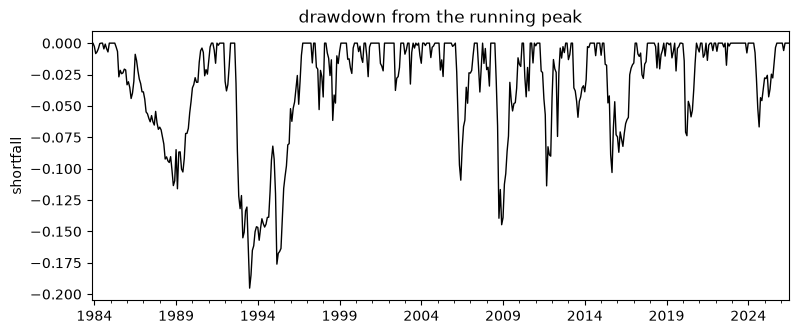

In [4]:
ax = perf.drawdown().plot(figsize=(9, 3.5), color="black", linewidth=1)
ax.set_title("drawdown from the running peak")
ax.set_ylabel("shortfall")
plt.show()

## HAC standard errors

A plain standard error of the mean, $s/\sqrt{T}$, assumes each period's return is drawn
independently of the last. Monthly carry returns are not: the interest differentials the signal
sorts on move slowly, so a currency's position this month and its position last month share most
of the same information, and the returns that follow inherit some of that persistence. Treating
the returns as independent understates how uncertain the mean really is.

`HAC.covariance` replaces the plain variance with a long-run covariance that lets nearby periods
correlate. For a demeaned series (or set of series) $x_t$, with
$\hat\Gamma_j = \frac{1}{T}\sum_{t=j+1}^{T} x_t x_{t-j}'$ and $L$ the chosen number of lags,

$$\hat S = \hat\Gamma_0 + \sum_{j=1}^{L}\left(1 - \frac{j}{L+1}\right)
\left(\hat\Gamma_j + \hat\Gamma_j'\right)$$

The Bartlett weight $1 - j/(L+1)$ is what keeps $\hat S$ positive semi-definite: without it, adding
more lags could push the estimated variance negative. `mean_se` does not call this method
directly. For a single series it hands the same Newey-West idea to statsmodels' OLS machinery
instead, a different implementation of a closely related estimator. `HAC(0).mean_se` should
reduce that machinery to the plain formula $\sqrt{\hat\Gamma_0/T}$ once there is nothing left to
correct for, and it very nearly does: statsmodels' sandwich estimator carries its own small-sample
adjustment that has nothing to do with lags, so the two agree closely rather than exactly. The
check below states that tolerance explicitly, at one percent, and prints all four figures so the
size of the gap is visible rather than hidden behind a passing assertion.

In [5]:
r = book.returns().dropna()
plain = float(r.std() / np.sqrt(len(r)))
hac0, hac6 = HAC(0), HAC(6)
# statsmodels applies a degrees of freedom correction the textbook formula does not, so
# these agree closely rather than exactly.
assert abs(hac0.mean_se(r) / plain - 1.0) < 0.01, "HAC at zero lags is not the plain error"
print(f"plain standard error   {plain:.8f}")
print(f"HAC at 0 lags          {hac0.mean_se(r):.8f}")
print(f"HAC at 6 lags          {hac6.mean_se(r):.8f}")
print(f"t statistic at 6 lags  {hac6.t_stat(r):.2f}")

plain standard error   0.00084948
HAC at 0 lags          0.00084865
HAC at 6 lags          0.00088171
t statistic at 6 lags  5.73


## What the lag choice costs

Every t statistic elsewhere in this notebook, and everywhere else in the repository, inherits one
particular value of `lags`. The table below runs the same return series through `HAC` at five
different choices, from no correction at all to two years of overlap.

In [6]:
pd.Series({lag: HAC(lag).t_stat(r) for lag in [0, 3, 6, 12, 24]},
          name="t statistic").round(3)

0     5.955
3     5.528
6     5.732
12    5.827
24    5.597
Name: t statistic, dtype: float64

The t statistic drifts across that range but never comes close to crossing into insignificance:
whichever of these five lag choices is used, the mean carry return sits many standard errors from
zero. The default of 6 lags, printed as 5.73 above, falls inside that range rather than at either
extreme, so quoting it is a choice among reasonable choices rather than the only defensible number.

## Standard errors for every moment

`moment_ses` extends the same delta-method machinery to the other four moments `Performance`
reports. Volatility, Sharpe, skew and excess kurtosis each get a standard error the same way the
mean does: stack the estimating equations for the first four central moments, take their long-run
covariance, and push it through each moment's own gradient. `summary(with_se=True)` calls it once
per column and lines the standard errors up under the point estimates they belong to.

In [7]:
print(hac6.moment_ses(r).round(5).to_dict())
Performance(book.returns()).summary(with_se=True).round(4).T

{'mean': 0.00088, 'volatility': 0.00103, 'sharpe': 0.05085, 'skew': 0.18492, 'excess_kurtosis': 0.43402}


,return
mean,0.0606
volatility,0.0665
sharpe,0.9117
skew,-0.3786
kurtosis,1.5129
win_rate,0.6282
worst,-0.0787
max_drawdown,-0.1952
mean_se,0.0106
n_obs,511.0000


## Realized volatility from daily data

`Performance.volatility` above described the strategy's own monthly returns. `Realized` asks a
different question about the market underneath it: how much the individual currencies moved day
to day, before any of that gets aggregated into a book. `factor` resamples daily log spot returns
to a chosen frequency, takes the standard deviation within each period per currency, and averages
that across the cross-section, so each value below is one period's typical daily volatility rather
than a volatility computed from monthly observations.

In [8]:
from fxcarry import Realized

realized = Realized().factor(np.log(daily).diff(), "M")
print(realized.tail(3).round(5).to_dict())

{Timestamp('2026-05-31 00:00:00'): 0.00394, Timestamp('2026-06-30 00:00:00'): 0.00396, Timestamp('2026-07-31 00:00:00'): 0.00342}


## FactorModel: dollar and carry factors on the five buckets

`FactorModel` runs one time-series regression per test asset, `Book.buckets(5)`'s five quintiles
here, against a set of factors: `DOL`, the cross-sectional average of all five buckets, and `HML`,
the return of the top bucket minus the bottom. Both factors are themselves built from the same
five buckets being explained, which is standard for a currency cross-section but worth naming.

In [9]:
from fxcarry import FactorModel

buckets = book.buckets(5)
dollar = buckets.mean(axis=1).rename("DOL")
carry_factor = (buckets[5] - buckets[1]).rename("HML")
# alpha_t is added to the brief's fit table so section 8's honesty note about which
# rows are informative can point at a printed number rather than an unverified claim.
fit = FactorModel(buckets, pd.concat([dollar, carry_factor], axis=1)).fit()
fit["alpha_t"] = fit["alpha"] / fit["alpha_se"]
fit.round(4)

,alpha,alpha_se,DOL_beta,DOL_se,HML_beta,HML_se,r2,alpha_t
1,-0.0000,0.0004,0.9882,0.0254,-0.4104,0.0314,0.8786,-0.0509
2,-0.0008,0.0003,0.9961,0.0359,-0.1272,0.0210,0.8215,-2.3334
3,0.0003,0.0004,0.9999,0.0347,-0.0712,0.0239,0.8026,0.6818
4,0.0006,0.0005,1.0276,0.0451,0.0192,0.0388,0.7761,1.1218
5,-0.0000,0.0004,0.9882,0.0254,0.5896,0.0314,0.9384,-0.0509


`HML` is bucket 5 minus bucket 1, so bucket 1 and bucket 5 are pushed toward opposite-signed
loadings on it by construction: bucket 5's return is added into `HML` and bucket 1's is
subtracted, and each bucket also makes up a fifth of `DOL`. Reading either extreme bucket's `HML`
loading as evidence of anything is reading back a definition. The middle three buckets carry the
information instead, with the `HML` loading rising from bucket 2 through bucket 4, and every
bucket's alpha is a legitimate result, including the two extremes, since none of the five returns
was used to define what an alpha should equal. Bucket 2 is the only one with an alpha t statistic
larger than 2 in absolute value; the rest sit closer to zero than a five-bucket, two-factor fit
with this much noise can resolve.

## LinearSDF: pricing the cross-section

`LinearSDF` estimates a single linear discount factor instead of running one regression per asset,
and asks it to price every test asset at once through one moment condition. The discount factor is

$$m_t = 1 - (f_t - \bar f)'b$$

and the moment condition is that every test asset prices to zero on average, $E[z_t m_t] = 0$ for
each column $z$ of `buckets`. `b` is the loading GMM assigns each factor inside that discount
factor; `risk_premia` is the compensation per unit of factor exposure implied by `b`, `b` pushed
through the factor covariance.

In [10]:
from fxcarry import LinearSDF

result = LinearSDF(buckets.dropna(), pd.concat([dollar, carry_factor], axis=1)).fit()
print(f"b            {result.b.round(3).to_dict()}")
print(f"risk premia  {result.risk_premia.round(5).to_dict()}")
print(f"cross sectional r2 {result.r2:.3f}")
print(f"J statistic {result.j_stat:.2f} on {result.n_assets - result.n_factors} "
      f"degrees of freedom, p = {result.j_pvalue:.3f}")
pd.DataFrame({"realized": result.realized, "predicted": result.predicted,
              "pricing error": result.pricing_errors}).round(5)

b            {'DOL': -1.748, 'HML': 9.365}


risk premia  {'DOL': 0.00055, 'HML': 0.00562}
cross sectional r2 0.916
J statistic 7.26 on 3 degrees of freedom, p = 0.064


,realized,predicted,pricing error
1,-0.00164,-0.00176,0.00011
2,-0.00070,-0.00016,-0.00054
3,0.00075,0.00015,0.00060
4,0.00159,0.00068,0.00091
5,0.00446,0.00386,0.00060


The J statistic tests whether the five pricing errors above are jointly zero once sampling noise
is accounted for. It is not a measure of fit; it only says whether the errors are larger than what
the data could distinguish from zero. With five assets and two factors that test has three degrees
of freedom, and on a panel this size it has correspondingly little power: a p-value of 0.064 fails
to reject at conventional levels, but a genuinely mispriced model could produce a similar p-value
simply because there are too few independent moments here to catch it. The cross-sectional r2 of
0.916 says the line these two factors trace through the five mean returns passes close to all five
points. It does not say that line was fit to signal rather than to noise.

## RollingOLS, reached through the module

`RollingOLS` is not part of `fxcarry`'s top-level namespace. It sits in `fxcarry.stats` alongside
the estimators the rest of this notebook already imported directly, and reaching it needs the
module path: `from fxcarry.stats import RollingOLS`. Where `HAC` fits one number to a whole
sample, `RollingOLS` fits a slope at every row using only the data up to that row, expanding by
default rather than sliding a fixed window.

In [11]:
from fxcarry.stats import RollingOLS

fit = RollingOLS(min_periods=24).fit(curves.excess_return, curves.carry)
print("expanding slope of excess return on carry, latest row")
print(fit["beta"].iloc[-1].dropna().round(2).head(6).to_dict())

expanding slope of excess return on carry, latest row
{'AUD': 0.13, 'CAD': 0.05, 'CHF': 0.16, 'CZK': -0.41, 'DKK': 0.11, 'EUR': 0.24}


## Shrinkage, both entry points

`Shrinkage.blend` is the general convex combination, `(1 - weight) * raw + weight * target`, and
takes the weight as given. `Shrinkage.cross_section` is the specific case this repository actually
needs: an empirical-Bayes estimate of that weight for a cross-section of noisy means, pulling each
currency's annualized excess return toward the group's center by an amount set by how large its
own standard error is relative to how spread out the true means appear to be. The limiting case is
the check: when the standard errors dominate whatever spread the estimates show, the weight on the
target should reach 1, and the shrunk estimate should collapse onto it.

In [12]:
from fxcarry import Shrinkage

means = curves.excess_return.mean() * 12
ses = curves.excess_return.std() / np.sqrt(curves.excess_return.count()) * 12
shrunk = Shrinkage.cross_section(means, ses)
print(shrunk.round(4).head(6))

noisy = Shrinkage.cross_section(means, ses * 50)
assert (noisy["weight"].dropna() > 0.99).all(), "huge noise did not collapse to the target"
print(f"\nwith the standard errors inflated fiftyfold every weight is "
      f"{noisy['weight'].dropna().min():.4f}: the cross section carries no information")

     shrunk  weight
AUD  0.0110  0.7006
CAD  0.0039  0.5310
CHF  0.0055  0.6806
CZK  0.0086  0.7726
DKK  0.0055  0.6508
EUR  0.0031  0.7020

with the standard errors inflated fiftyfold every weight is 1.0000: the cross section carries no information


## Check yourself

**Why is a plain standard error wrong for monthly strategy returns?** It assumes each month's
return carries no information about the next. Carry positions come from interest differentials
that barely move month to month, so the sorted book holds close to the same currencies for
stretches at a time, and its returns inherit that persistence. `HAC` prices that persistence in:
at six lags its standard error, 0.00088171 above, sits above the plain figure of 0.00084948, and
the plain formula has no way to know it is missing that gap.

**What does a shrinkage weight of one mean?** That the estimate carries no information the target
does not already have. Inflating every standard error fiftyfold above pushed every weight to
1.0000, meaning `Shrinkage.cross_section` returned the cross-sectional mean for every currency and
discarded each one's own noisy estimate entirely, which is the right thing to do once the noise
swamps whatever real dispersion the means might carry.

**Why are shape statistics not annualized?** A mean and a variance both accumulate over a holding
period in a way that has a defined scaling rule, at rate $T$ and $\sqrt{T}$ respectively under
independence. Skewness and kurtosis describe the shape of one period's distribution, not a rate,
so there is no version of skew per year for `periods_per_year` to convert a per-period skew into.
`Performance` reports them per period for the same reason it reports `worst` per period: scaling
them would answer a question nobody asked.